# Imports

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Data Preperation for time-dependence

In [41]:
charging_data = pd.read_csv("../00_Productive_Data/charging_data_clean.csv", parse_dates=["connectionTime","disconnectTime","doneChargingTime"])
charging_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60922 entries, 0 to 60921
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        60922 non-null  int64  
 1   id                60922 non-null  object 
 2   connectionTime    60922 non-null  object 
 3   disconnectTime    60922 non-null  object 
 4   doneChargingTime  60922 non-null  object 
 5   kWhDelivered      60922 non-null  float64
 6   sessionID         60922 non-null  object 
 7   siteID            60922 non-null  int64  
 8   spaceID           60922 non-null  object 
 9   timezone          60922 non-null  object 
 10  userID            44637 non-null  float64
 11  userInputs        44637 non-null  object 
dtypes: float64(2), int64(2), object(8)
memory usage: 5.6+ MB


In [42]:
date_columns = ["connectionTime", "disconnectTime", "doneChargingTime"]

for data in date_columns:
    charging_data[data] = pd.to_datetime(charging_data[data], utc=True)

def convert_to_local(row): 
    tz = row["timezone"]
    for col in date_columns:
        ts = row[col]
        if pd.isna(ts):
            continue 
        row[col] = ts.tz_convert(tz)
    return row 

charging_data = charging_data.apply(convert_to_local, axis=1)

charging_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60922 entries, 0 to 60921
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype                              
---  ------            --------------  -----                              
 0   Unnamed: 0        60922 non-null  int64                              
 1   id                60922 non-null  object                             
 2   connectionTime    60922 non-null  datetime64[ns, America/Los_Angeles]
 3   disconnectTime    60922 non-null  datetime64[ns, America/Los_Angeles]
 4   doneChargingTime  60922 non-null  datetime64[ns, America/Los_Angeles]
 5   kWhDelivered      60922 non-null  float64                            
 6   sessionID         60922 non-null  object                             
 7   siteID            60922 non-null  int64                              
 8   spaceID           60922 non-null  object                             
 9   timezone          60922 non-null  object                     

In [43]:
# überlegen ob es vielleicht auch ohne lambda eleganter geht
charging_data["year"] = charging_data["connectionTime"].map(lambda x: x.year)
charging_data["month"] = charging_data["connectionTime"].map(lambda x: x.month)
charging_data["weekday"] = charging_data["connectionTime"].map(lambda x: x.weekday())
charging_data["connectionHour"] = charging_data["connectionTime"].map(lambda x: x.hour)
charging_data["disconnectionHour"] = charging_data["disconnectTime"].map(lambda x: x.hour)

charging_data["chargingDuration"] = (charging_data["doneChargingTime"] - charging_data["connectionTime"]).dt.total_seconds() / 3600
charging_data["connectionDuration"] = (charging_data["disconnectTime"] - charging_data["connectionTime"]).dt.total_seconds() / 3600
charging_data["chargingEfficiency"] = charging_data["chargingDuration"]/charging_data["connectionDuration"]


charging_data.head()

,Unnamed: 0,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,timezone,userID,userInputs,year,month,weekday,connectionHour,disconnectionHour,chargingDuration,connectionDuration,chargingEfficiency
0,52871,5c36631ef9af8b4639a8e5bc,2018-10-08 15:44:47-07:00,2018-10-08 17:59:14-07:00,2018-10-08 17:56:20-07:00,10.208,1_1_193_825_2018-10-08 22:44:47.505042,1,AG-1F01,America/Los_Angeles,NaN,NaN,2018,10,0,15,17,2.192500,2.240833,0.978431
1,52886,5c366352f9af8b4639a8e5cb,2018-10-09 06:08:55-07:00,2018-10-09 15:03:56-07:00,2018-10-09 10:33:24-07:00,11.837,1_1_193_825_2018-10-09 13:08:55.279362,1,AG-1F01,America/Los_Angeles,NaN,NaN,2018,10,1,6,15,4.408056,8.916944,0.494346
2,52942,5c366352f9af8b4639a8e603,2018-10-09 15:26:40-07:00,2018-10-09 19:48:12-07:00,2018-10-09 19:28:29-07:00,12.034,1_1_193_825_2018-10-09 22:26:39.626134,1,AG-1F01,America/Los_Angeles,383.0,"[{'WhPerMile': 400, 'kWhRequested': 15.2, 'mil...",2018,10,1,15,19,4.030278,4.358889,0.924611
3,52958,5c36639ff9af8b4639a8e613,2018-10-10 06:15:02-07:00,2018-10-10 15:30:44-07:00,2018-10-10 10:56:11-07:00,11.985,1_1_193_825_2018-10-10 13:15:01.608497,1,AG-1F01,America/Los_Angeles,NaN,NaN,2018,10,2,6,15,4.685833,9.261667,0.505938
4,53015,5c36639ff9af8b4639a8e64c,2018-10-10 15:52:56-07:00,2018-10-10 17:34:00-07:00,2018-10-10 17:11:04-07:00,7.863,1_1_193_825_2018-10-10 22:52:55.607786,1,AG-1F01,America/Los_Angeles,NaN,NaN,2018,10,2,15,17,1.302222,1.684444,0.773087


In [44]:
# Preparing Splitting of Data based on time variables and charging sites
weekdays = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
months = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]

site1 = charging_data[charging_data["siteID"] == 1]
site2 = charging_data[charging_data["siteID"] == 2]

In [45]:
charging_data_hours = charging_data.groupby("connectionHour")
site1_hours = site1.groupby("connectionHour")
site2_hours = site2.groupby("connectionHour")

charging_data_weekdays = charging_data.groupby("weekday")
site1_weekdays = site1.groupby("weekday")
site2_weekdays = site2.groupby("weekday")

charging_data_months = charging_data.groupby("month")
site1_months = site1.groupby("month")
site2_months = site2.groupby("month")

# Visualization

## Number of started sessions

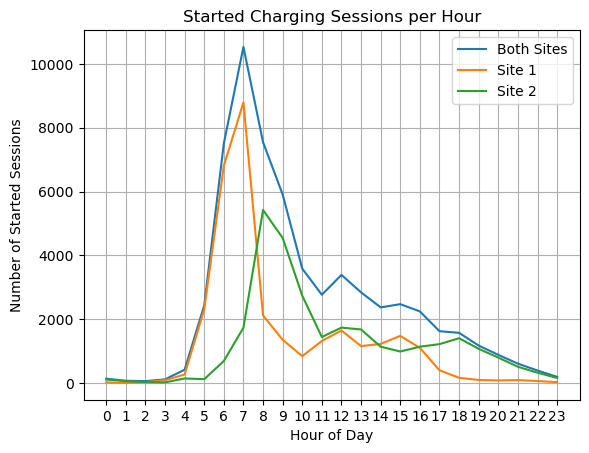

In [46]:
sessions_per_hour = (charging_data_hours.size())
sessions_per_hour_site1 = (site1_hours.size())
sessions_per_hour_site2 = (site2_hours.size())

plt.figure()
plt.plot(sessions_per_hour.index, sessions_per_hour.values, label="Both Sites")
plt.plot(sessions_per_hour_site1.index, sessions_per_hour_site1.values, label="Site 1")
plt.plot(sessions_per_hour_site2.index, sessions_per_hour_site2.values, label="Site 2")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Started Sessions")
plt.title("Started Charging Sessions per Hour")
plt.xticks(range(0, 24))
plt.grid(True)
plt.legend()
plt.show()


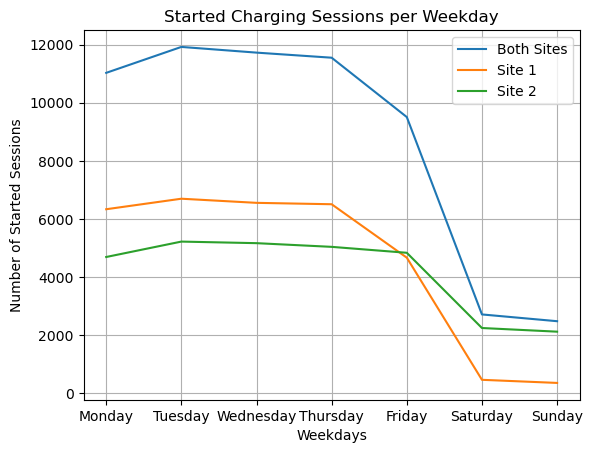

In [47]:
sessions_per_weekday = (charging_data_weekdays.size())
sessions_per_weekday_site1 = (site1_weekdays.size())
sessions_per_weekday_site2 = (site2_weekdays.size())

plt.figure()
plt.plot(sessions_per_weekday.index, sessions_per_weekday.values, label="Both Sites")
plt.plot(sessions_per_weekday_site1.index, sessions_per_weekday_site1.values, label="Site 1")
plt.plot(sessions_per_weekday_site2.index, sessions_per_weekday_site2.values, label="Site 2")
plt.xlabel("Weekdays")
plt.ylabel("Number of Started Sessions")
plt.title("Started Charging Sessions per Weekday")
plt.xticks(range(7), labels=weekdays)
plt.grid(True)
plt.legend()
plt.show()

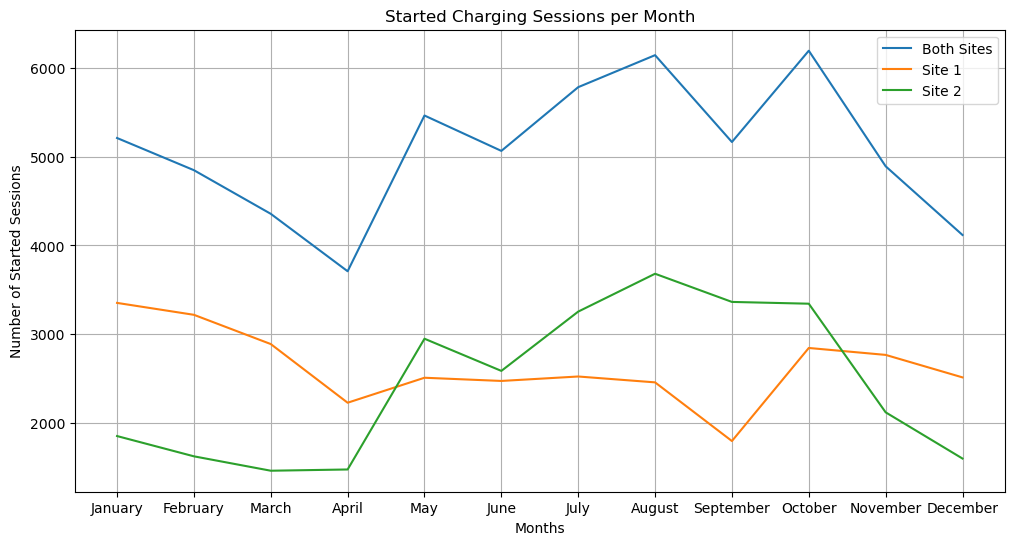

In [ ]:
sessions_per_month = (charging_data_months.size())
sessions_per_month_site1 = (site1_months.size())
sessions_per_month_site2 = (site2_months.size())

plt.figure(figsize=(12,6))
plt.plot(sessions_per_month.index, sessions_per_month.values, label="Both Sites")
plt.plot(sessions_per_month_site1.index, sessions_per_month_site1.values, label="Site 1")
plt.plot(sessions_per_month_site2.index, sessions_per_month_site2.values, label="Site 2")
plt.xlabel("Month")
plt.ylabel("Number of Started Sessions")
plt.title("Started Charging Sessions per Month")
plt.xticks(range(1, 13), labels=months)
plt.grid(True)
plt.legend()
plt.show()

## Charging Efficiency

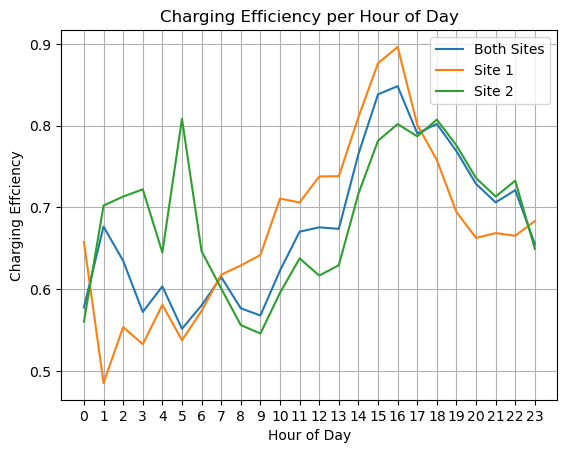

In [50]:
efficiency_per_hour = charging_data_hours["chargingEfficiency"].mean()
efficiency_per_hour_site1 = site1_hours["chargingEfficiency"].mean()
efficiency_per_hour_site2 = site2_hours["chargingEfficiency"].mean()

plt.figure()
plt.plot(efficiency_per_hour.index, efficiency_per_hour.values, label="Both Sites")
plt.plot(efficiency_per_hour_site1.index, efficiency_per_hour_site1.values, label="Site 1")
plt.plot(efficiency_per_hour_site2.index, efficiency_per_hour_site2.values, label="Site 2")
plt.xlabel("Hour of Day")
plt.ylabel("Charging Effciency")
plt.title("Charging Efficiency per Hour of Day")
plt.xticks(range(24))
plt.grid(True)
plt.legend()
plt.show()

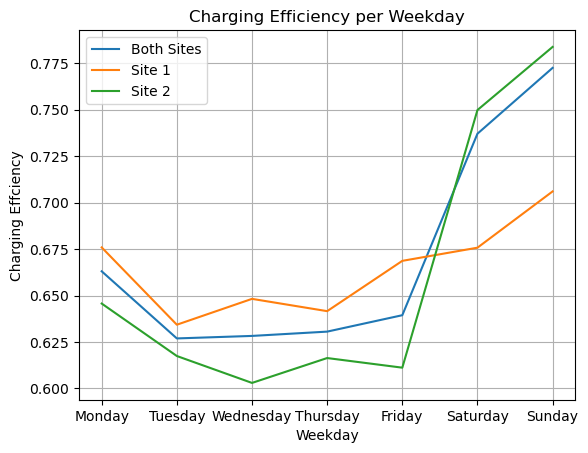

In [66]:
efficiency_per_weekday = charging_data_weekdays["chargingEfficiency"].mean()
efficiency_per_weekday_site1 = site1_weekdays["chargingEfficiency"].mean()
efficiency_per_weekday_site2 = site2_weekdays["chargingEfficiency"].mean()

plt.figure()
plt.plot(efficiency_per_weekday.index, efficiency_per_weekday.values, label="Both Sites")
plt.plot(efficiency_per_weekday_site1.index, efficiency_per_weekday_site1.values, label="Site 1")
plt.plot(efficiency_per_weekday_site2.index, efficiency_per_weekday_site2.values, label="Site 2")
plt.xlabel("Weekday")
plt.ylabel("Charging Effciency")
plt.title("Charging Efficiency per Weekday")
plt.xticks(range(7), labels=weekdays)
plt.grid(True)
plt.legend()
plt.show()

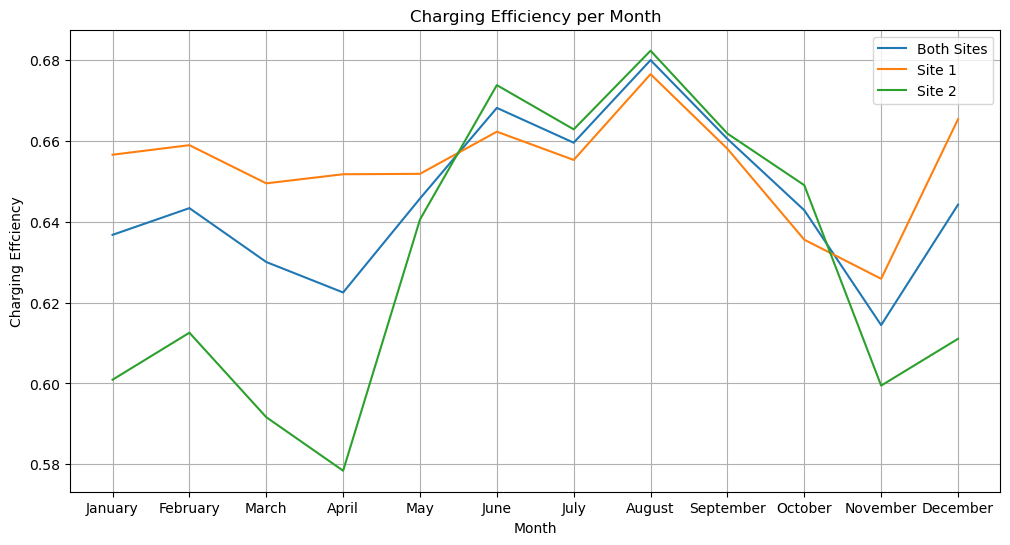

In [69]:
efficiency_per_month = charging_data_months["chargingEfficiency"].mean()
efficiency_per_month_site1 = site1_months["chargingEfficiency"].mean()
efficiency_per_month_site2 = site2_months["chargingEfficiency"].mean()

plt.figure(figsize=(12,6))
plt.plot(efficiency_per_month.index, efficiency_per_month.values, label="Both Sites")
plt.plot(efficiency_per_month_site1.index, efficiency_per_month_site1.values, label="Site 1")
plt.plot(efficiency_per_month_site2.index, efficiency_per_month_site2.values, label="Site 2")
plt.xlabel("Month")
plt.ylabel("Charging Effciency")
plt.title("Charging Efficiency per Month")
plt.xticks(range(1,13), labels=months)
plt.grid(True)
plt.legend()
plt.show()

## Relation between requested and devlivered kWh

def extract_latest_kwh_requested(user_input):
    if isinstance(user_input, list) and len(user_input) > 0:
        if len(user_input) == 1:
            return user_input[0][1]
        else:
            latest_entry = max(user_input, key=lambda x: x[4])
            return latest_entry[1]
    else:
        return 0

charging_data["kWhRequested_latest"] = charging_data["userInputs"].apply(extract_latest_kwh_requested)

## Utilization rate

## Delivered kWh

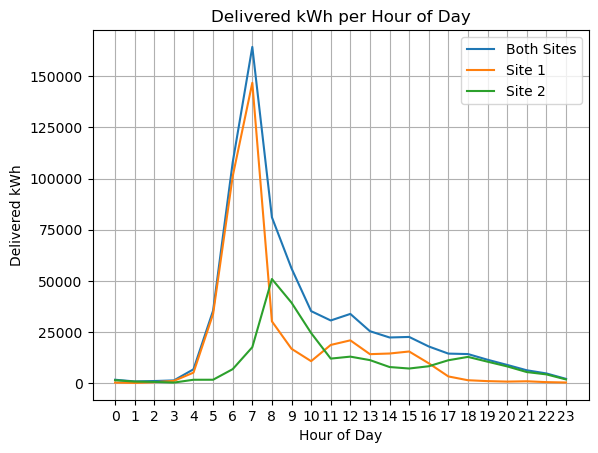

In [65]:
kWh_per_hour = charging_data_hours["kWhDelivered"].sum()
kWh_per_hour_site1 = site1_hours["kWhDelivered"].sum()
kWh_per_hour_site2 = site2_hours["kWhDelivered"].sum()

plt.figure()
plt.plot(kWh_per_hour.index, kWh_per_hour.values, label="Both Sites")
plt.plot(kWh_per_hour_site1.index, kWh_per_hour_site1.values, label="Site 1")
plt.plot(kWh_per_hour_site2.index, kWh_per_hour_site2.values, label="Site 2")
plt.xlabel("Hour of Day")
plt.ylabel("Delivered kWh")
plt.title("Delivered kWh per Hour of Day")
plt.xticks(range(24))
plt.grid(True)
plt.legend()
plt.show()

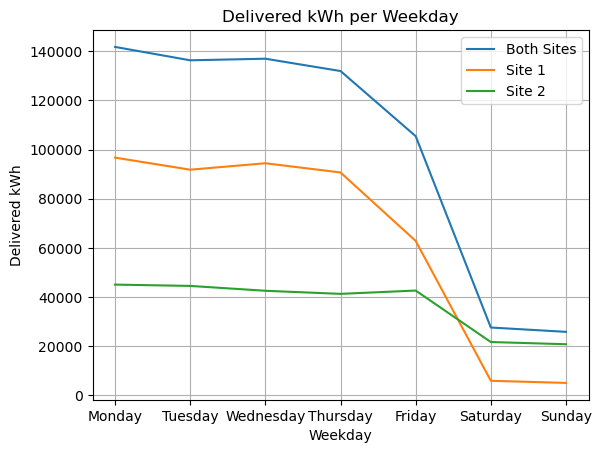

In [70]:
kWh_per_weekday = charging_data_weekdays["kWhDelivered"].sum()
kWh_per_weekday_site1 = site1_weekdays["kWhDelivered"].sum()
kWh_per_weekday_site2 = site2_weekdays["kWhDelivered"].sum()

plt.figure()
plt.plot(kWh_per_weekday.index, kWh_per_weekday.values, label="Both Sites")
plt.plot(kWh_per_weekday_site1.index, kWh_per_weekday_site1.values, label="Site 1")
plt.plot(kWh_per_weekday_site2.index, kWh_per_weekday_site2.values, label="Site 2")
plt.xlabel("Weekday")
plt.ylabel("Delivered kWh")
plt.title("Delivered kWh per Weekday")
plt.xticks(range(7), labels=weekdays)
plt.grid(True)
plt.legend()
plt.show()

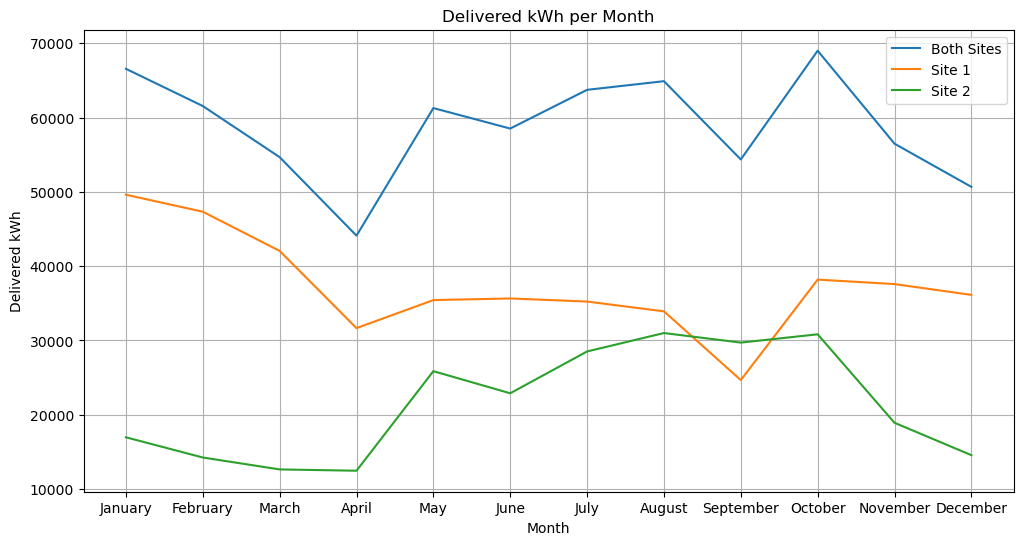

In [74]:
kWh_per_month = charging_data_months["kWhDelivered"].sum()
kWh_per_month_site1 = site1_months["kWhDelivered"].sum()
kWh_per_month_site2 = site2_months["kWhDelivered"].sum()

plt.figure(figsize=(12,6))
plt.plot(kWh_per_month.index, kWh_per_month.values, label="Both Sites")
plt.plot(kWh_per_month_site1.index, kWh_per_month_site1.values, label="Site 1")
plt.plot(kWh_per_month_site2.index, kWh_per_month_site2.values, label="Site 2")
plt.xlabel("Month")
plt.ylabel("Delivered kWh")
plt.title("Delivered kWh per Month")
plt.xticks(range(1,13), labels=months)
plt.grid(True)
plt.legend()
plt.show()